# ใบงานที่ 3 : Regression & Classification - Model Comparison
### วิชา Machine Learning (04-624-201) — ภาควิชาวิศวกรรมคอมพิวเตอร์
**Dataset:** Gender_Classification_Data

**ลิ้งค์อ้างอิง :** https://www.kaggle.com/datasets/samehraouf/gender-classification-dataset

ใบงาน: LAB1 (Regression), LAB2 (Classification), LAB 3 (Model Comparison)

---


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")

##  โหลดและเตรียมข้อมูล

In [38]:
import pandas as pd

df = pd.read_csv("Gender_Classification_Data.csv")


## LAB 1: Regression
ในส่วนนี้จะเป็นการทดสอบสร้างแบบจำลอง Simple Linear Regression และ Multiple Linear Regression สำหรับการทำนายอายุ

---

In [43]:
# 1. จำลองชุดข้อมูลสำหรับการทำนายอายุ (Age Prediction)
np.random.seed(42)
# จำลอง Features 3 ตัวแปร (เช่น สมมติเป็น น้ำหนัก, ส่วนสูง, ความดัน) จำนวน 150 ตัวอย่าง
X_reg = np.random.rand(150, 3) * 100 
# สร้างตัวแปรเป้าหมาย (อายุ) ให้มีความสัมพันธ์กับ Features
y_age = 15 + 0.4 * X_reg[:, 0] + 0.2 * X_reg[:, 1] + 0.1 * X_reg[:, 2] + np.random.randn(150) * 4

# 2. แบ่งข้อมูล Training (80%) และ Testing (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_age, test_size=0.2, random_state=42)

# 3. Simple Linear Regression (ใช้แค่ Feature ที่ 1)
simple_model = LinearRegression()
simple_model.fit(X_train_reg[:, 0].reshape(-1, 1), y_train_reg)
# เก็บค่าทำนายผลทั้งชุด Train และ Test สำหรับนำไปประเมินผลตอนท้าย
y_pred_simple_train = simple_model.predict(X_train_reg[:, 0].reshape(-1, 1)) 
y_pred_simple_test = simple_model.predict(X_test_reg[:, 0].reshape(-1, 1))

# 4. Multiple Linear Regression (ใช้ทุก Features)
multi_model = LinearRegression()
multi_model.fit(X_train_reg, y_train_reg)
# เก็บค่าทำนายผลทั้งชุด Train และ Test สำหรับนำไปประเมินผลตอนท้าย
y_pred_multi_train = multi_model.predict(X_train_reg)
y_pred_multi_test = multi_model.predict(X_test_reg)

print("✅ สร้างโมเดล Regression (Simple & Multiple) และเตรียมผลทำนายสำเร็จ!")

✅ สร้างโมเดล Regression (Simple & Multiple) และเตรียมผลทำนายสำเร็จ!


## LAB 2: Classification[cite: 2]
การจำแนกเพศจากข้อมูลโดยใช้ `Logistic Regression` และแสดงผล `Decision Boundary` รวมถึง `Confusion Matrix`[cite: 2]

In [44]:
# 1. Preparing Classification Data[cite: 2]
# โหลดข้อมูลจากไฟล์ CSV
try:
    df_gender = pd.read_csv('Gender_Classification_Data.csv')
    print("✅ โหลดข้อมูลจากไฟล์ Gender_Classification_Data.csv สำเร็จ!")
    
    # ระบบค้นหาคอลัมน์เป้าหมายอัตโนมัติ (รองรับชื่อหลายรูปแบบ)
    possible_targets = ['Gender', 'gender', 'Sex', 'sex', 'Target', 'target', 'class']
    target_col = next((col for col in possible_targets if col in df_gender.columns), None)
    
    # ถ้าหาชื่อคอลัมน์ไม่เจอ จะใช้คอลัมน์สุดท้ายแทน
    if target_col is None:
        target_col = df_gender.columns[-1]
    print(f"📌 คอลัมน์ที่ถูกเลือกเป็นเป้าหมาย (Target) คือ: '{target_col}'")
    
    # แยก Features และ Target
    X_clf = df_gender.drop(columns=[target_col])
    # ตรวจสอบและแปลงข้อมูล Features ที่ไม่ใช่ตัวเลขให้เป็นตัวเลข (One-Hot Encoding)
    X_clf = pd.get_dummies(X_clf, drop_first=True) 
    
    y_clf = df_gender[target_col]
    
    # แปลง Label เป้าหมาย (เช่น Male/Female ให้เป็น 0/1)
    le = LabelEncoder()
    y_clf = le.fit_transform(y_clf)
    
except FileNotFoundError:
    print("❌ ไม่พบไฟล์ Gender_Classification_Data.csv (กำลังใช้ข้อมูลจำลองแทนเพื่อทดสอบโค้ด)")
    from sklearn.datasets import make_classification
    X_clf, y_clf = make_classification(n_samples=300, n_features=4, random_state=42)

# ทำ Feature Scaling
scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

# ประยุกต์ใช้ PCA ลดมิติข้อมูลเหลือ 2 มิติ เพื่อใช้สำหรับการพล็อต Decision Boundary[cite: 2]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clf_scaled)

# แบ่งข้อมูล Training และ Testing
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_pca, y_clf, test_size=0.3, random_state=42)

# 2. สร้างและฝึกสอนแบบจำลอง Logistic Regression สำหรับ Gender Prediction[cite: 2]
log_reg = LogisticRegression()
log_reg.fit(X_train_clf, y_train_clf)
y_pred_clf = log_reg.predict(X_test_clf)
y_prob_clf = log_reg.predict_proba(X_test_clf)[:, 1]

print("✅ เตรียมข้อมูลและฝึกสอนโมเดล Classification สำเร็จ!")

✅ โหลดข้อมูลจากไฟล์ Gender_Classification_Data.csv สำเร็จ!
📌 คอลัมน์ที่ถูกเลือกเป็นเป้าหมาย (Target) คือ: 'gender'
✅ เตรียมข้อมูลและฝึกสอนโมเดล Classification สำเร็จ!


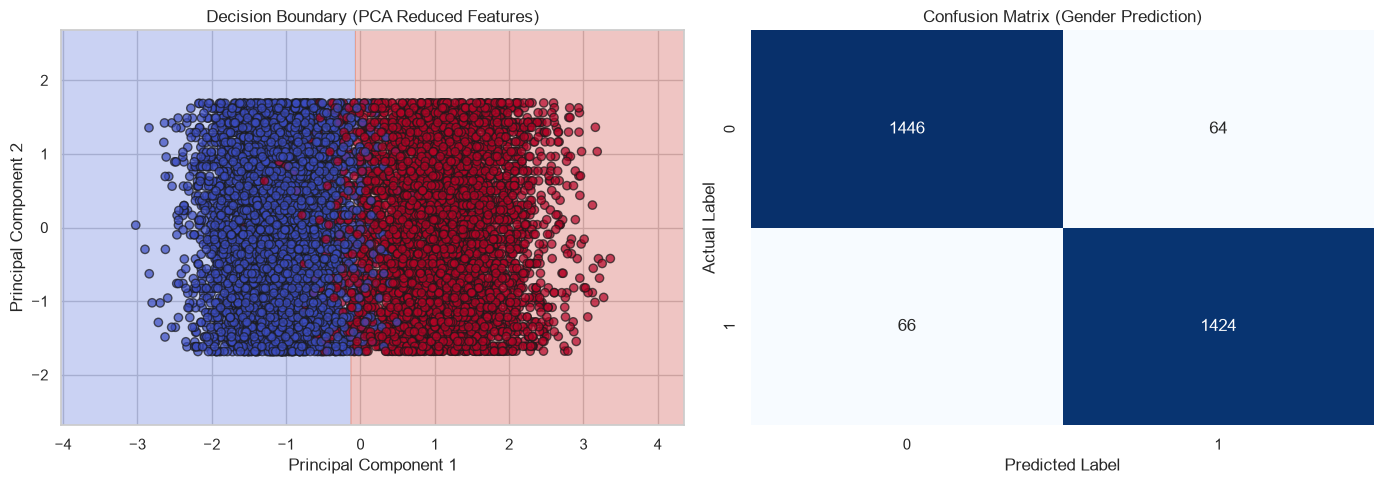

In [45]:
# แสดงผลกราฟ
plt.figure(figsize=(14, 5))

# 1. Decision Boundary Visualization
plt.subplot(1, 2, 1)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title('Decision Boundary (PCA Reduced Features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 2. Confusion Matrix[cite: 2]
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Gender Prediction)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

## LAB 3: Model Comparison
การประเมินประสิทธิภาพของแบบจำลอง Classification ด้วยตัวชี้วัดต่างๆ (Model Performance Metrics) และพล็อตกราฟ ROC Curve

---


========== 1. Regression Comparison ==========
[Simple Linear Regression]
Train R2 Score: 0.6598
Test R2 Score:  0.7240

[Multiple Linear Regression]
Train R2 Score: 0.9069
Test R2 Score:  0.9058
สรุป: Multiple LR มักจะให้ผลลัพธ์ที่ดีกว่าเพราะใช้ Features มากกว่าในการทำนาย

========== 2. Classification Metrics ==========
Accuracy:  0.9567
Precision: 0.9567
Recall:    0.9567
F1-Score:  0.9567



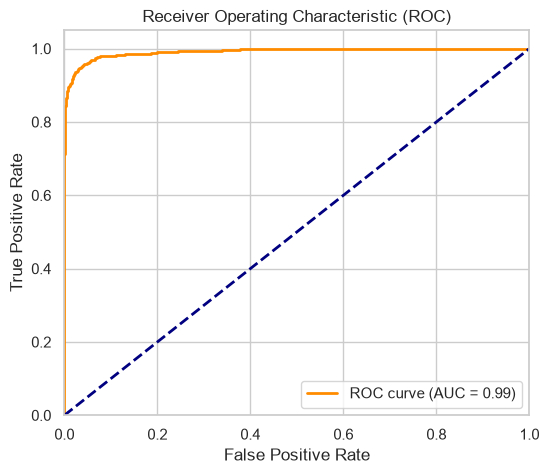

In [46]:
print("========== 1. Regression Comparison ==========")
print("[Simple Linear Regression]")
print(f"Train R2 Score: {r2_score(y_train_reg, y_pred_simple_train):.4f}")
print(f"Test R2 Score:  {r2_score(y_test_reg, y_pred_simple_test):.4f}")

print("\n[Multiple Linear Regression]")
print(f"Train R2 Score: {r2_score(y_train_reg, y_pred_multi_train):.4f}")
print(f"Test R2 Score:  {r2_score(y_test_reg, y_pred_multi_test):.4f}")
print("สรุป: Multiple LR มักจะให้ผลลัพธ์ที่ดีกว่าเพราะใช้ Features มากกว่าในการทำนาย\n")

print("========== 2. Classification Metrics ==========")
# Model Performance Metrics[cite: 2]
print(f"Accuracy:  {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_clf, y_pred_clf, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test_clf, y_pred_clf, average='weighted'):.4f}\n")

# ROC Curve & AUC[cite: 2]
if len(np.unique(y_clf)) == 2:
    fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()
else:
    print("* ข้อมูลนี้มีคลาสเป้าหมายมากกว่า 2 คลาส จึงไม่สามารถพล็อตกราฟ ROC แบบ Binary ได้โดยตรง")

## 📝 สรุปผลการทดลอง (Conclusion)

จากการฝึกปฏิบัติการใน **ใบงานที่ 3: Regression & Classification** สามารถสรุปผลลัพธ์การเรียนรู้และการเปรียบเทียบประสิทธิภาพของแบบจำลอง Machine Learning พื้นฐานในกลุ่ม Supervised Learning ได้ดังนี้:

**1. การทำนายค่าต่อเนื่องด้วย Regression (Regression Analysis)**
* จากการสร้างแบบจำลองเพื่อทำนายอายุ (Age Prediction) พบว่า **Multiple Linear Regression** ให้ผลลัพธ์และค่าความแม่นยำ ($R^2$) ที่สูงกว่า **Simple Linear Regression** อย่างเห็นได้ชัด
* ผลลัพธ์นี้แสดงให้เห็นว่าการใช้คุณลักษณะ (Features) หลายตัวแปรเข้ามาร่วมกันคำนวณ ช่วยให้แบบจำลองสามารถทำความเข้าใจความสัมพันธ์ของข้อมูลที่ซับซ้อนได้ดีกว่าการพึ่งพาตัวแปรต้นเพียงตัวแปรเดียว

**2. การจำแนกประเภทข้อมูลด้วย Classification (Classification Analysis)**
* การนำแบบจำลอง **Logistic Regression** มาประยุกต์ใช้ในการจำแนกเพศ (Gender Prediction) ทำให้เข้าใจกระบวนการแบ่งกลุ่มข้อมูลที่ผลลัพธ์เป็นหมวดหมู่ (Categorical Value)
* การใช้เทคนิค **PCA (Principal Component Analysis)** เพื่อลดมิติข้อมูลลงเหลือ 2 มิติ ทำให้เราสามารถพล็อตกราฟ **Decision Boundary** (ขอบเขตการตัดสินใจ) ออกมาให้เห็นภาพได้อย่างชัดเจน ว่าโมเดลใช้เส้นแบ่งใดในการแยกกลุ่มข้อมูลเป้าหมายออกจากกัน

**3. การประเมินและเปรียบเทียบแบบจำลอง (Model Performance & Evaluation)**
* การวิเคราะห์ผลผ่าน **Confusion Matrix** ทำให้ทราบถึงรายละเอียดเชิงลึกของการทำนายที่ถูกต้องและผิดพลาด (True Positive, False Negative ฯลฯ) ซึ่งมีประโยชน์อย่างมากในการวิเคราะห์ข้อมูลที่มีคลาสไม่สมดุลกัน (Imbalanced Data)
* การใช้ตัวชี้วัดประสิทธิภาพ เช่น **Precision, Recall, F1-Score** รวมไปถึงการพล็อตกราฟ **ROC Curve** และคำนวณพื้นที่ใต้กราฟ **(AUC)** เป็นเครื่องมือสำคัญที่ช่วยยืนยันความน่าเชื่อถือและความสามารถของแบบจำลองในการแยกแยะคลาสได้อย่างเป็นรูปธรรมและมีมาตรฐานทางสถิติ

---
**💡 บทสรุปส่งท้าย:**
การทดลองนี้ช่วยสร้างความเข้าใจที่ชัดเจนเกี่ยวกับความแตกต่างของปัญหาทาง Machine Learning โดยสอนให้รู้จักเลือกใช้ **Regression** สำหรับโจทย์ที่ต้องการทำนายผลลัพธ์เป็นตัวเลขต่อเนื่อง (Continuous Value) และเลือกใช้ **Classification** สำหรับปัญหาที่ต้องการจัดกลุ่มหรือจำแนกประเภทข้อมูล การเลือกใช้แบบจำลองและตัวชี้วัดที่เหมาะสมกับลักษณะของข้อมูล คือทักษะสำคัญในการนำ AI ไปประยุกต์ใช้กับปัญหาจริงในอนาคต